# Contrastive Pre-training (InfoNCE) — ICU Mortality Prediction

In [1]:
import os
import sys


IS_COLAB = False

if "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ:
    print("Status: Running on Google Colab")
    IS_COLAB = True
    from google.colab import drive

    drive.mount("/content/drive")
else:
    print("Status: Running Locally")


Status: Running on Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize as sk_normalize
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


TRIPLET_VARS = [
    "Albumin", "ALP", "ALT", "AST", "Bilirubin", "BUN", "Cholesterol",
    "Creatinine", "DiasABP", "FiO2", "GCS", "Glucose", "HCO3", "HCT",
    "HR", "K", "Lactate", "Mg", "MAP", "MechVent", "Na", "NIDiasABP",
    "NIMAP", "NISysABP", "PaCO2", "PaO2", "pH", "Platelets", "RespRate",
    "SaO2", "SysABP", "Temp", "TroponinI", "TroponinT", "Urine", "WBC",
    "age", "height_cm", "weight_kg", "gender",
]

DATA_DIR = "./drive/MyDrive/data"

N_VARS  = len(TRIPLET_VARS)   # 40 clinical variables
PAD_IDX = N_VARS               # index 40 reserved for padding
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")
print(f"Clinical variables: {N_VARS}  |  PAD index: {PAD_IDX}  |  DATA_DIR: {DATA_DIR}")

PyTorch 2.10.0+cu128  |  device: cuda
Clinical variables: 40  |  PAD index: 40  |  DATA_DIR: ./drive/MyDrive/data


## 1 — Load triplet data

In [31]:
df_a = pd.read_parquet(os.path.join(DATA_DIR, "set_a_triplet.parquet"))
df_b = pd.read_parquet(os.path.join(DATA_DIR, "set_b_triplet.parquet"))
df_c = pd.read_parquet(os.path.join(DATA_DIR, "set_c_triplet.parquet"))

print(f"Set A: {df_a.shape}  |  Set B: {df_b.shape}  |  Set C: {df_c.shape}")
for name, df in [("A", df_a), ("B", df_b), ("C", df_c)]:
    pos = df.groupby("PatientID")["in_hospital_death"].first().mean()
    print(f"  Set {name}: {df['PatientID'].nunique()} patients  |  positive rate: {pos:.3f}")


Set A: (1618740, 45)  |  Set B: (1622803, 45)  |  Set C: (1623953, 45)
  Set A: 4000 patients  |  positive rate: 0.139
  Set B: 4000 patients  |  positive rate: 0.142
  Set C: 4000 patients  |  positive rate: 0.146


## 2 — Sequence lengths & MAX_LEN

In [32]:
all_lengths = pd.concat([
    df_a.groupby('PatientID').size(),
    df_b.groupby('PatientID').size(),
    df_c.groupby('PatientID').size(),
])

print('Event counts across all patients:')
print(f'  min={all_lengths.min()}  p50={all_lengths.median():.0f}'
      f'  p95={all_lengths.quantile(.95):.0f}  max={all_lengths.max()}')

# Cap at p95 — the global max (1321) is an outlier; padding to it dilutes attention
# over ~70% padding tokens for the median patient.
MAX_LEN = int(all_lengths.quantile(0.95))
print(f'\nMAX_LEN (p95 cap): {MAX_LEN}')

Event counts across all patients:
  min=2  p50=394  p95=609  max=1321

MAX_LEN (p95 cap): 609


## 3 — Augmentations for positive pairs

In [33]:
# ── Augmentation hyper-parameters ──────────────────────────────────────
# Event-level dropout
DROPOUT_P        = 0.35   # per-event drop prob for dynamic continuous events
STATIC_DROPOUT_P = 0.40   # per-event drop prob for categorical / binary tokens
# Continuous jitter
JITTER_SIGMA     = 0.25   # std of Gaussian noise added to continuous values
# Whole-variable channel masking
VAR_MASK_FRAC    = 0.15   # fraction of all variable channels dropped per view
# Temporal crop — each view sees a random contiguous subwindow
CROP_FRAC_MIN    = 0.60   # keep at least 60 % of the normalised time range
CROP_FRAC_MAX    = 0.80   # keep at most  80 % of the normalised time range

CAT_VARS = [10, 19, 39]   # GCS, MechVent, gender — no jitter; higher dropout


def augment(t: np.ndarray, z: np.ndarray, v: np.ndarray) -> tuple:
    """
    Four-stage augmentation that destroys patient-identity signals
    while preserving clinical-state information.

    1. Random temporal crop     — each view sees 60-80 % of the time window.
    2. Whole-variable masking   — all tokens of VAR_MASK_FRAC random channels
                                  are dropped, preventing fingerprinting via
                                  'this patient had lactate measured at hour 3'.
    3. Per-event selective dropout — higher rate for categorical/binary tokens.
    4. Selective jitter         — Gaussian noise on continuous values only.
    """
    # ── 1. Temporal crop ─────────────────────────────────────────────────
    frac      = np.random.uniform(CROP_FRAC_MIN, CROP_FRAC_MAX)
    t_min, t_max = float(t.min()), float(t.max())
    t_range   = max(t_max - t_min, 1e-6)
    crop_len  = frac * t_range
    crop_start = t_min + np.random.uniform(0.0, t_range - crop_len)
    crop_end   = crop_start + crop_len
    in_crop    = (t >= crop_start) & (t <= crop_end)
    in_crop[t == 0.0] = True  # static events (t=0) always survive
    t, z, v = t[in_crop], z[in_crop], v[in_crop]

    # ── 2. Whole-variable masking ─────────────────────────────────────
    n_mask = max(1, int(N_VARS * VAR_MASK_FRAC))
    masked_vars   = np.random.choice(N_VARS, size=n_mask, replace=False)
    not_masked = ~np.isin(z, masked_vars)
    if not_masked.sum() >= 2:          # only apply if ≥2 events survive
        t, z, v = t[not_masked], z[not_masked], v[not_masked]

    L = len(t)
    if L < 2:                          # degenerate — return as-is
        return t, z, v

    # ── 3. Per-event selective dropout ───────────────────────────────
    mask_probs = np.full(L, DROPOUT_P, dtype=np.float64)
    for cat_idx in CAT_VARS:
        mask_probs[z == cat_idx] = STATIC_DROPOUT_P
    keep = np.random.rand(L) >= mask_probs
    if keep.sum() < 2:                 # always keep at least 2 events
        keep = np.ones(L, dtype=bool)
        keep[np.random.choice(L, max(0, L - 2), replace=False)] = False
    t, z, v = t[keep], z[keep], v[keep].copy()

    # ── 4. Selective jitter (continuous only) ────────────────────────
    jitter_mask = np.ones(len(z), dtype=bool)
    for cat_idx in CAT_VARS:
        jitter_mask[z == cat_idx] = False
    noise = np.random.normal(0.0, JITTER_SIGMA, size=v.shape).astype(np.float32)
    v[jitter_mask] += noise[jitter_mask]

    return t, z, v


# ── Sanity check ─────────────────────────────────────────────────────
_sample = df_a[df_a['PatientID'] == df_a['PatientID'].iloc[0]]
_t = _sample['t'].to_numpy(dtype=np.float32)
_z = _sample['variable_idx'].to_numpy(dtype=np.int64)
_v = _sample['v'].to_numpy(dtype=np.float32)

_t1, _z1, _v1 = augment(_t, _z, _v)
_t2, _z2, _v2 = augment(_t, _z, _v)

print(f'Original length : {len(_t)}')
print(f'View 1 length   : {len(_t1)}  (kept {len(_t1)/len(_t)*100:.0f}%)')
print(f'View 2 length   : {len(_t2)}  (kept {len(_t2)/len(_t)*100:.0f}%)')
for name, idx in [('GCS', 10), ('MechVent', 19), ('gender', 39)]:
    orig_vals = _v[_z == idx]
    v1_vals   = _v1[_z1 == idx]
    if len(orig_vals) and len(v1_vals):
        delta = abs(v1_vals[0] - orig_vals[0])
        print(f'{name:10s} jitter delta={delta:.6f}  {"OK (no jitter)" if delta < 1e-9 else "WARN"}')

Original length : 268
View 1 length   : 99  (kept 37%)
View 2 length   : 106  (kept 40%)
GCS        jitter delta=0.000000  OK (no jitter)


## 4 — Datasets & DataLoaders

In [34]:
def _pad_sequence(
    t: np.ndarray, z: np.ndarray, v: np.ndarray, max_len: int, pad_idx: int
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Truncate to max_len (oldest events dropped) then pad; return (var_idx, continuous, pad_mask)."""
    if len(t) > max_len:           # truncate — keep the most recent max_len events
        t, z, v = t[-max_len:], z[-max_len:], v[-max_len:]
    L   = len(t)
    pad = max_len - L
    var_idx    = np.concatenate([z, np.full(pad, pad_idx, dtype=np.int64)])
    t_pad      = np.concatenate([t, np.zeros(pad, dtype=np.float32)])
    v_pad      = np.concatenate([v, np.zeros(pad, dtype=np.float32)])
    continuous = np.stack([t_pad, v_pad], axis=-1)      # (max_len, 2)
    pad_mask   = np.array([False] * L + [True] * pad, dtype=bool)
    return torch.from_numpy(var_idx), torch.from_numpy(continuous), torch.from_numpy(pad_mask)


class ContrastiveDataset(Dataset):
    """
    Returns two independently augmented views of the same patient sequence.
    Labels are NOT used during contrastive pre-training.
    """
    def __init__(self, df: pd.DataFrame, max_len: int, pad_idx: int):
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.sequences: list[tuple] = []
        for _, group in df.sort_values('t').groupby('PatientID', sort=False):
            t = group['t'].to_numpy(dtype=np.float32)
            z = group['variable_idx'].to_numpy(dtype=np.int64)
            v = group['v'].to_numpy(dtype=np.float32)
            self.sequences.append((t, z, v))

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int):
        t, z, v = self.sequences[idx]
        view1 = _pad_sequence(*augment(t, z, v), self.max_len, self.pad_idx)
        view2 = _pad_sequence(*augment(t, z, v), self.max_len, self.pad_idx)
        return view1, view2


class SupervisedDataset(Dataset):
    """Standard labelled dataset for the linear-probe fine-tuning stage."""
    def __init__(self, df: pd.DataFrame, max_len: int, pad_idx: int):
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.samples: list[tuple] = []
        for _, group in df.sort_values('t').groupby('PatientID', sort=False):
            t   = group['t'].to_numpy(dtype=np.float32)
            z   = group['variable_idx'].to_numpy(dtype=np.int64)
            v   = group['v'].to_numpy(dtype=np.float32)
            lbl = float(group['in_hospital_death'].iloc[0])
            self.samples.append((t, z, v, lbl))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        t, z, v, lbl = self.samples[idx]
        var_idx, continuous, pad_mask = _pad_sequence(t, z, v, self.max_len, self.pad_idx)
        return var_idx, continuous, pad_mask, torch.tensor(lbl, dtype=torch.float32)


PRETRAIN_BATCH = 128
PROBE_BATCH    = 64

pretrain_loader    = DataLoader(ContrastiveDataset(df_a, MAX_LEN, PAD_IDX),
                                batch_size=PRETRAIN_BATCH, shuffle=True, drop_last=True)
probe_train_loader = DataLoader(SupervisedDataset(df_a, MAX_LEN, PAD_IDX),
                                batch_size=PROBE_BATCH, shuffle=True, drop_last=True)
probe_val_loader   = DataLoader(SupervisedDataset(df_b, MAX_LEN, PAD_IDX),
                                batch_size=PROBE_BATCH, shuffle=False)
probe_test_loader  = DataLoader(SupervisedDataset(df_c, MAX_LEN, PAD_IDX),
                                batch_size=PROBE_BATCH, shuffle=False)

print(f'Pre-train batches / epoch : {len(pretrain_loader)}  (batch={PRETRAIN_BATCH})')
print(f'Linear-probe train batches: {len(probe_train_loader)}')

Pre-train batches / epoch : 31  (batch=128)
Linear-probe train batches: 62


## 5 — TripletTransformer backbone

In [35]:
class TripletTransformer(nn.Module):
    """
    Identical architecture to Q2.3b.
    The encode() method returns the pooled embedding (used by the contrastive model).
    The forward() method additionally applies the classification head (used by the
    linear probe).
    """
    def __init__(
        self,
        n_vars: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 1,
        d_ff: int = 128,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.var_embed  = nn.Embedding(n_vars + 1, d_model, padding_idx=n_vars)
        self.cont_proj  = nn.Linear(2, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, 1)

    def encode(
        self,
        var_idx: torch.Tensor,    # (B, L)
        continuous: torch.Tensor, # (B, L, 2)
        pad_mask: torch.Tensor,   # (B, L)  True = PAD
    ) -> torch.Tensor:
        """Return the masked-average-pooled embedding (B, d_model)."""
        x = self.var_embed(var_idx) + self.cont_proj(continuous)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        real = ~pad_mask
        x = (x * real.unsqueeze(-1)).sum(dim=1)
        x = x / real.sum(dim=1, keepdim=True).clamp(min=1)
        return self.dropout(x)

    def forward(
        self,
        var_idx: torch.Tensor,
        continuous: torch.Tensor,
        pad_mask: torch.Tensor,
    ) -> torch.Tensor:
        """Return the classification logit (B,)."""
        return self.classifier(self.encode(var_idx, continuous, pad_mask)).squeeze(-1)


## 6 — ContrastiveTripletTransformer & InfoNCE loss

In [36]:
class ContrastiveTripletTransformer(nn.Module):
    """
    Siamese wrapper around TripletTransformer for InfoNCE pre-training.

    Both views of a patient pass through the SAME shared encoder.
    A non-linear projection head (SimCLR-style) maps the embedding into
    the contrastive space where NT-Xent loss is applied.
    Discarding the projector after pre-training preserves rich representations
    in the encoder that are not collapsed by the loss signal.
    """
    def __init__(self, base_encoder: TripletTransformer,
                 embedding_dim: int = 64, projection_dim: int = 128):
        super().__init__()
        self.encoder = base_encoder

        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, projection_dim),
            nn.BatchNorm1d(projection_dim),
            nn.ReLU(),
            nn.Linear(projection_dim, projection_dim),
        )

    def forward(
        self,
        var_idx: torch.Tensor,
        continuous: torch.Tensor,
        pad_mask: torch.Tensor,
    ) -> torch.Tensor:
        """Return L2-normalised projection (B, projection_dim)."""
        h = self.encoder.encode(var_idx, continuous, pad_mask)
        z = self.projector(h)
        return F.normalize(z, dim=-1)


def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.1) -> torch.Tensor:
    """
    Normalized Temperature-scaled Cross Entropy (NT-Xent / InfoNCE).

    For a batch of N patients with views z1 and z2:
      - Concatenate into z = [z1 ; z2]  →  (2N, D)
      - Build cosine similarity matrix  →  (2N, 2N)  (inputs are already L2-normalised)
      - For each anchor i, the positive is its paired view; all 2N-2 others are negatives
      - Loss = mean cross-entropy over all 2N anchors
    """
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)             # (2N, D)

    # Cosine similarity (z already normalised → dot product = cosine sim)
    sim = torch.mm(z, z.T) / temperature       # (2N, 2N)

    # Mask out self-similarity on the diagonal (a sample is not its own negative)
    self_mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(self_mask, float("-inf"))

    # Positive index: view i pairs with view i+N, and i+N pairs with i
    labels = torch.cat([
        torch.arange(N, 2 * N, device=z.device),
        torch.arange(N,        device=z.device),
    ])

    return F.cross_entropy(sim, labels)


# Instantiate and print parameter counts
_backbone  = TripletTransformer(n_vars=N_VARS, d_model=64, nhead=4, num_layers=1, d_ff=128, dropout=0.4)
_cl_model  = ContrastiveTripletTransformer(_backbone, embedding_dim=64, projection_dim=128)
n_enc      = sum(p.numel() for p in _backbone.parameters() if p.requires_grad)
n_proj     = sum(p.numel() for p in _cl_model.projector.parameters() if p.requires_grad)
print(f"Encoder params    : {n_enc:,}")
print(f"Projector params  : {n_proj:,}")
print(f"Total (pretrain)  : {n_enc + n_proj:,}")
del _backbone, _cl_model


Encoder params    : 36,353
Projector params  : 25,088
Total (pretrain)  : 61,441


## 7 — InfoNCE pre-training  (no labels)

In [37]:
PRETRAIN_EPOCHS = 150
PRETRAIN_LR     = 1e-3
TEMPERATURE     = 0.5
backbone  = TripletTransformer(n_vars=N_VARS, d_model=64, nhead=4,
                               num_layers=1, d_ff=128,
                               dropout=0.15).to(DEVICE)

cl_model  = ContrastiveTripletTransformer(backbone, embedding_dim=64,
                                          projection_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(cl_model.parameters(), lr=PRETRAIN_LR, weight_decay=1e-4)

pretrain_history = []
print(f"{'Epoch':>6}  {'InfoNCE loss':>12}")
print('-' * 22)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    cl_model.train()
    total_loss, n_batches = 0.0, 0

    for (z1_idx, z1_cont, z1_mask), (z2_idx, z2_cont, z2_mask) in pretrain_loader:
        optimizer.zero_grad()
        emb1 = cl_model(z1_idx.to(DEVICE), z1_cont.to(DEVICE), z1_mask.to(DEVICE))
        emb2 = cl_model(z2_idx.to(DEVICE), z2_cont.to(DEVICE), z2_mask.to(DEVICE))
        loss = nt_xent_loss(emb1, emb2, temperature=TEMPERATURE)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1

    avg_loss = total_loss / n_batches
    pretrain_history.append({'epoch': epoch, 'loss': avg_loss})

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {avg_loss:>12.4f}')

print('\nPre-training complete.')

 Epoch  InfoNCE loss
----------------------
     1        4.6585
    10        4.1148
    20        4.0526
    30        4.0191
    40        3.9929
    50        3.9924
    60        3.9772
    70        3.9629
    80        3.9514
    90        3.9484
   100        3.9466
   110        3.9409
   120        3.9359
   130        3.9347
   140        3.9364
   150        3.9283

Pre-training complete.


## 8 — Pre-training loss curve

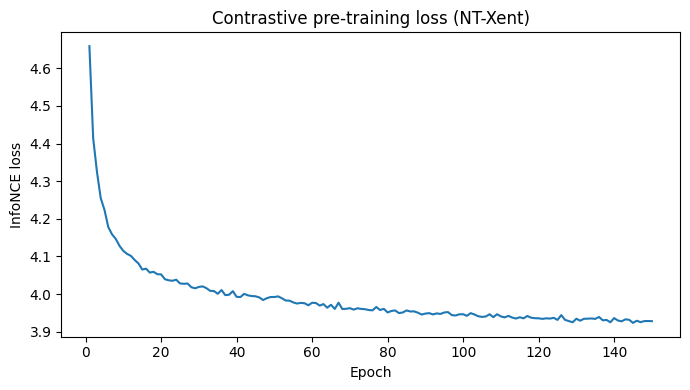

In [38]:
pt_hist = pd.DataFrame(pretrain_history)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pt_hist["epoch"], pt_hist["loss"])
ax.set_xlabel("Epoch")
ax.set_ylabel("InfoNCE loss")
ax.set_title("Contrastive pre-training loss (NT-Xent)")
plt.tight_layout()
plt.show()


## 9 — Linear probe  (frozen encoder + single linear head)

In [39]:
PROBE_EPOCHS = 100
PROBE_LR     = 1e-3
PATIENCE     = 15

# ── Freeze the pre-trained encoder ───────────────────────────────────────────
for param in backbone.parameters():
    param.requires_grad = False

# ── Attach a fresh linear classification head ─────────────────────────────
linear_head = nn.Linear(64, 1).to(DEVICE)

# Only the linear head is optimised
probe_optimizer = torch.optim.Adam(linear_head.parameters(), lr=PROBE_LR, weight_decay=1e-4)

y_train_lbl = torch.tensor(
    df_a.groupby("PatientID")["in_hospital_death"].first().to_numpy(dtype=np.float32)
)
pos_weight = torch.tensor([(y_train_lbl == 0).sum() / (y_train_lbl == 1).sum()]).to(DEVICE)
probe_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def evaluate_probe(loader: DataLoader) -> tuple[float, float, np.ndarray]:
    backbone.eval()
    linear_head.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for z_idx, cont, mask, y in loader:
            emb    = backbone.encode(z_idx.to(DEVICE), cont.to(DEVICE), mask.to(DEVICE))
            logits = linear_head(emb)
            logits_all.append(logits.cpu())
            labels_all.append(y)
    logits = torch.cat(logits_all).numpy().ravel()
    labels = torch.cat(labels_all).numpy()
    probs  = torch.sigmoid(torch.from_numpy(logits)).numpy()
    return roc_auc_score(labels, probs), average_precision_score(labels, probs), probs


best_val_auroc = 0.0
best_epoch     = 0
best_head_state = None
patience_count = 0
probe_history  = []

print(f"{'Epoch':>6}  {'Train loss':>10}  {'Val AuROC':>9}  {'Val AuPRC':>9}")
print("-" * 44)

for epoch in range(1, PROBE_EPOCHS + 1):
    backbone.eval()       # encoder stays frozen / eval mode
    linear_head.train()
    total_loss = 0.0

    for z_idx, cont, mask, y in probe_train_loader:
        probe_optimizer.zero_grad()
        with torch.no_grad():
            emb = backbone.encode(z_idx.to(DEVICE), cont.to(DEVICE), mask.to(DEVICE))
        logits = linear_head(emb).squeeze(-1)
        loss   = probe_criterion(logits, y.to(DEVICE))
        loss.backward()
        probe_optimizer.step()
        total_loss += loss.item() * len(y)

    val_auroc, val_auprc, _ = evaluate_probe(probe_val_loader)
    avg_loss = total_loss / len(probe_train_loader.dataset)
    probe_history.append({"epoch": epoch, "loss": avg_loss,
                          "val_auroc": val_auroc, "val_auprc": val_auprc})

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {avg_loss:>10.4f}  {val_auroc:>9.4f}  {val_auprc:>9.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc  = val_auroc
        best_epoch      = epoch
        best_head_state = {k: v.clone() for k, v in linear_head.state_dict().items()}
        patience_count  = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch}  (no improvement for {PATIENCE} epochs)")
            break

linear_head.load_state_dict(best_head_state)
print(f"\nRestored best linear head — epoch {best_epoch}  val AuROC={best_val_auroc:.4f}")


 Epoch  Train loss  Val AuROC  Val AuPRC
--------------------------------------------
     1      1.1763     0.7017     0.3116
     5      1.0162     0.7666     0.3756
    10      0.9787     0.7743     0.3769
    15      0.9652     0.7777     0.3810
    20      0.9578     0.7800     0.3845
    25      0.9539     0.7812     0.3867
    30      0.9496     0.7820     0.3887
    35      0.9478     0.7825     0.3896
    40      0.9416     0.7828     0.3904
    45      0.9436     0.7832     0.3909
    50      0.9392     0.7834     0.3914
    55      0.9382     0.7834     0.3919
    60      0.9344     0.7833     0.3917
    65      0.9376     0.7835     0.3921
    70      0.9375     0.7831     0.3919
    75      0.9322     0.7832     0.3920
    80      0.9318     0.7833     0.3925

Early stop at epoch 82  (no improvement for 15 epochs)

Restored best linear head — epoch 67  val AuROC=0.7835


## 10 — Linear probe training curves

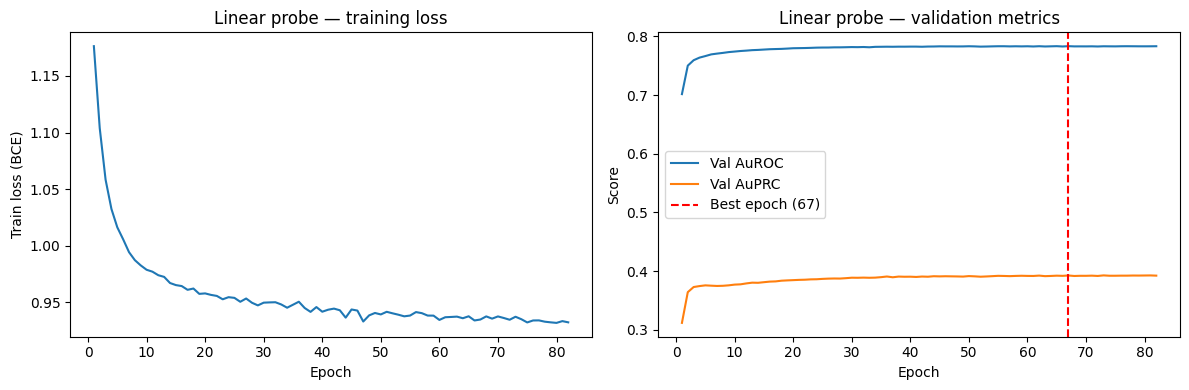

In [40]:
probe_hist = pd.DataFrame(probe_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(probe_hist["epoch"], probe_hist["loss"])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss (BCE)")
axes[0].set_title("Linear probe — training loss")

axes[1].plot(probe_hist["epoch"], probe_hist["val_auroc"], label="Val AuROC")
axes[1].plot(probe_hist["epoch"], probe_hist["val_auprc"], label="Val AuPRC")
axes[1].axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Linear probe — validation metrics")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11 — Test set C evaluation (AuROC & AuPRC)

Model                                     AuROC    AuPRC
--------------------------------------------------------
InfoNCE pre-train → Linear probe         0.7852   0.4131


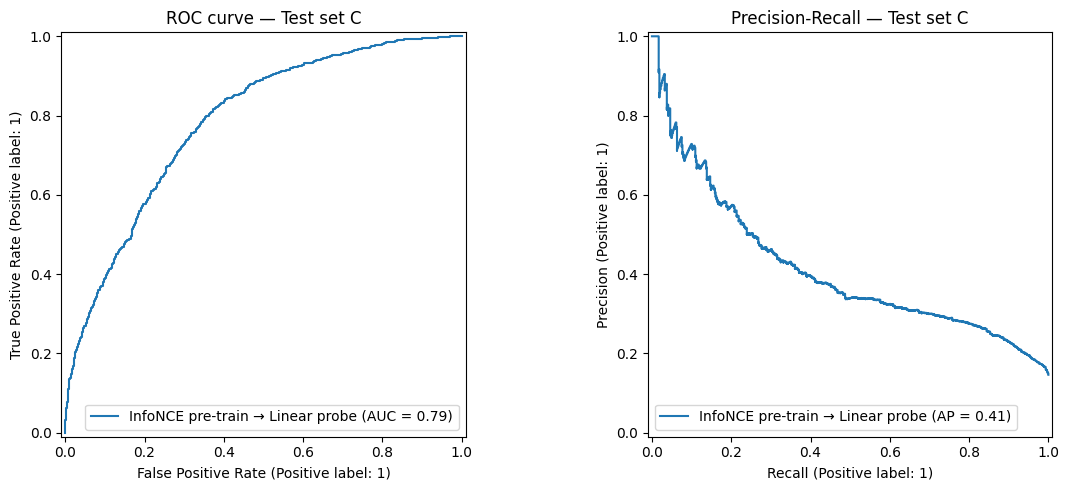

In [41]:
test_auroc, test_auprc, test_probs = evaluate_probe(probe_test_loader)

model_label = "InfoNCE pre-train → Linear probe"
print("=" * 56)
print(f"{'Model':<38}  {'AuROC':>7}  {'AuPRC':>7}")
print("-" * 56)
print(f"{model_label:<38}  {test_auroc:>7.4f}  {test_auprc:>7.4f}")
print("=" * 56)

y_test = torch.cat([y for _, _, _, y in probe_test_loader]).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_probs, name=model_label, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, test_probs, name=model_label, ax=axes[1])
axes[0].set_title("ROC curve — Test set C")
axes[1].set_title("Precision-Recall — Test set C")
plt.tight_layout()
plt.show()


## 12 — Extract embeddings from all splits

In [42]:
## ── Section 12: Extract all embeddings ────────────────────────────

backbone.eval()

def extract_embeddings(loader):
    embs, labels = [], []
    with torch.no_grad():
        for z_idx, cont, mask, y in loader:
            e = backbone.encode(z_idx.to(DEVICE), cont.to(DEVICE), mask.to(DEVICE))  # (B, d_model)
            embs.append(e.cpu().numpy())
            labels.append(y.numpy())
    return np.vstack(embs), np.concatenate(labels).astype(int)

# Re-use the supervised datasets / loaders built for the linear probe
emb_train, lbl_train = extract_embeddings(probe_train_loader)
emb_val,   lbl_val   = extract_embeddings(probe_val_loader)
emb_test,  lbl_test  = extract_embeddings(probe_test_loader)

emb_all   = np.vstack([emb_train, emb_val, emb_test])
lbl_all   = np.concatenate([lbl_train, lbl_val, lbl_test])
split_all = np.array(['train']*len(lbl_train) + ['val']*len(lbl_val) + ['test']*len(lbl_test))

print(f'Embeddings shape: {emb_all.shape}  |  deaths: {lbl_all.sum()} / {len(lbl_all)}')

Embeddings shape: (11968, 64)  |  deaths: 1701 / 11968


## 13 — t-SNE visualisation

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


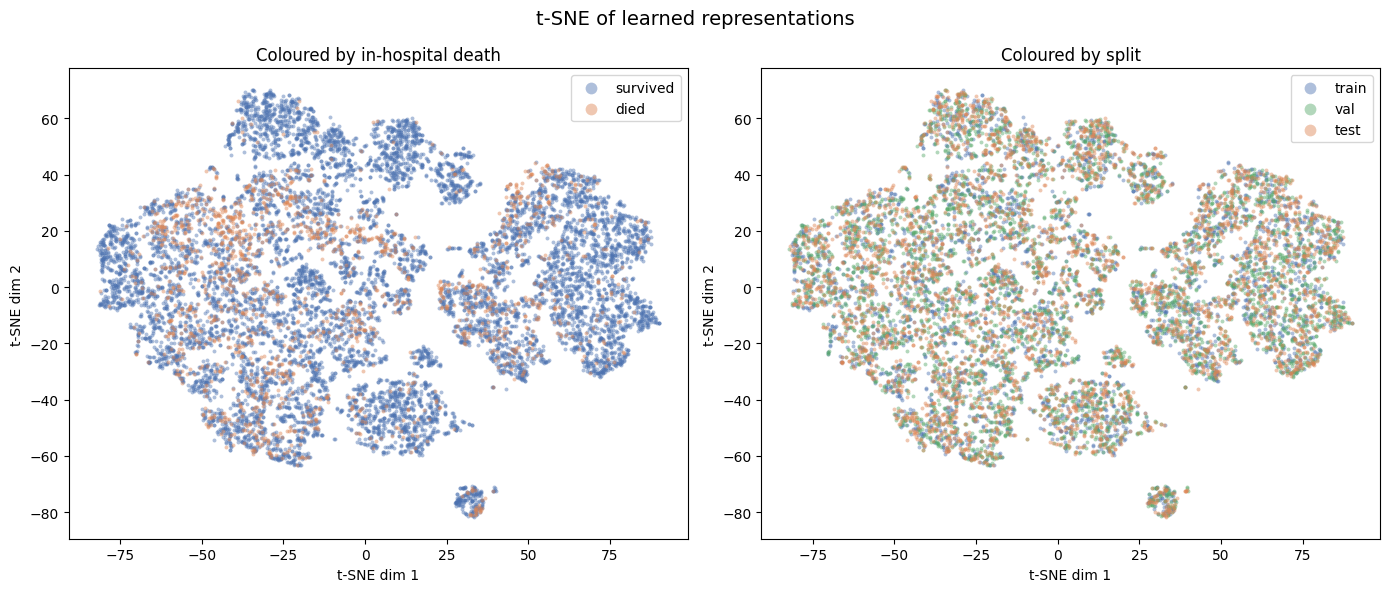

In [43]:
## ── Section 13: t-SNE visualisation
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
emb2_tsne = tsne.fit_transform(emb_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-SNE of learned representations', fontsize=14)

# — colour by mortality label —
ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

# — colour by split —
ax = axes[1]
split_colors = {'train': '#4c72b0', 'val': '#55a868', 'test': '#dd8452'}
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

plt.tight_layout()
plt.show()

## 14 — UMAP visualisation

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


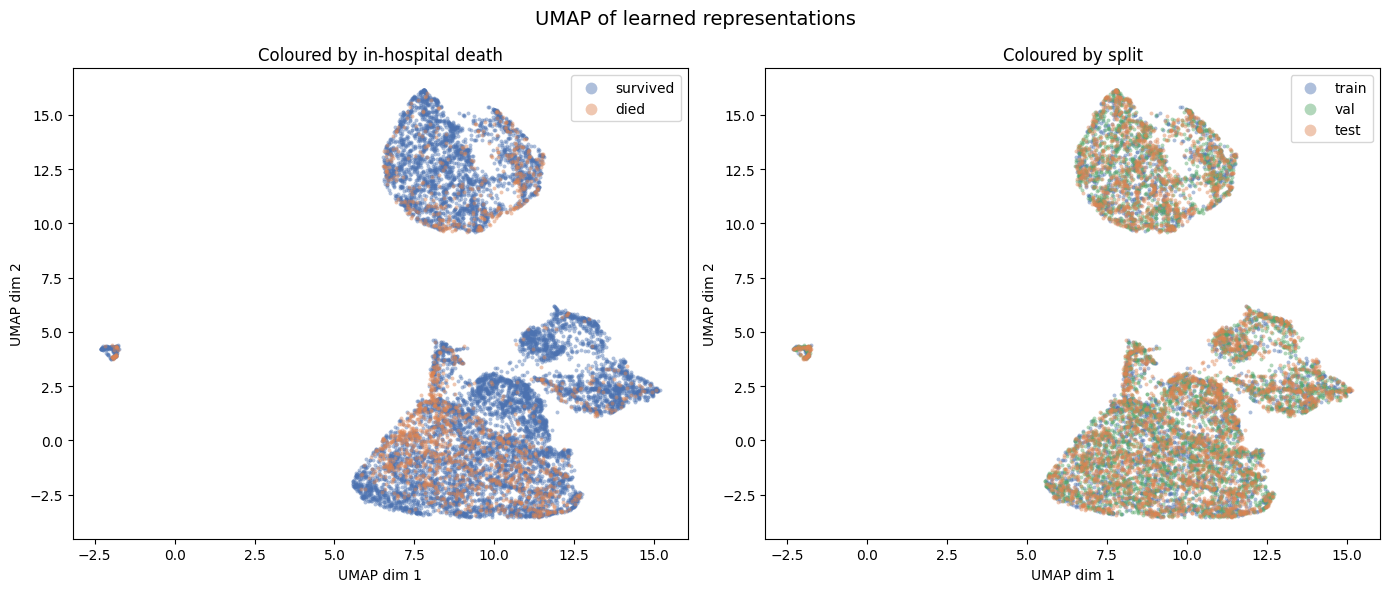

In [44]:
## ── Section 14: UMAP visualisation ────────────────────────────────

reducer    = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
emb2_umap  = reducer.fit_transform(emb_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('UMAP of learned representations', fontsize=14)

ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')

ax = axes[1]
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')

plt.tight_layout()
plt.show()

## 15 — Quantitative clustering metrics

In [45]:
## ── Section 15: Quantitative clustering metrics ────────────────────
from sklearn.preprocessing import normalize as sk_normalize


# 1. Silhouette score on raw embeddings (cosine distance)
emb_norm = sk_normalize(emb_all, norm='l2')
sil_cos = silhouette_score(emb_norm, lbl_all, metric='euclidean')  # l2-normed → equiv. cosine

# 2. Silhouette score on t-SNE 2-D projection (euclidean)
sil_tsne = silhouette_score(emb2_tsne, lbl_all, metric='euclidean')

# 3. k-Means (k=2) on raw embeddings → NMI & ARI vs true labels
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(emb_all)
nmi  = normalized_mutual_info_score(lbl_all, km_labels)
ari  = adjusted_rand_score(lbl_all, km_labels)

# 4. Print summary table
print()
print('=' * 52)
print(f'{'Metric':<36}  {'Value':>10}')
print('-' * 52)
print(f'{'Silhouette (cosine, raw emb)':<36}  {sil_cos:>10.4f}')
print(f'{'Silhouette (euclidean, t-SNE 2-D)':<36}  {sil_tsne:>10.4f}')
print(f'{'NMI  (k-Means k=2 vs labels)':<36}  {nmi:>10.4f}')
print(f'{'ARI  (k-Means k=2 vs labels)':<36}  {ari:>10.4f}')
print('=' * 52)
print()
print('Interpretation guide:')
print('  Silhouette in [-1, 1]; higher → more compact, well-separated clusters.')
print('  NMI  in [ 0, 1]; higher → k-Means clusters align better with labels.')
print('  ARI  in [-1, 1]; higher → stronger agreement with true mortality label.')


Metric                                     Value
----------------------------------------------------
Silhouette (cosine, raw emb)              0.0301
Silhouette (euclidean, t-SNE 2-D)        -0.0306
NMI  (k-Means k=2 vs labels)              0.0026
ARI  (k-Means k=2 vs labels)             -0.0135

Interpretation guide:
  Silhouette in [-1, 1]; higher → more compact, well-separated clusters.
  NMI  in [ 0, 1]; higher → k-Means clusters align better with labels.
  ARI  in [-1, 1]; higher → stronger agreement with true mortality label.


## 16 — Data-efficiency experiment: helpers

In [46]:
import copy

SUBSET_SIZES  = [100, 500, 1000]
SUB_EPOCHS    = 100
SUB_PATIENCE  = 15
SUB_LR        = 1e-3
SUB_BATCH     = 64

def make_subset_loader(df_full: pd.DataFrame, n_patients: int) -> DataLoader:
    """Sample n_patients from df_full (by PatientID) and return a supervised DataLoader."""
    pids = df_full['PatientID'].drop_duplicates().sample(n=n_patients, random_state=42)
    sub  = df_full[df_full['PatientID'].isin(pids)]
    return DataLoader(SupervisedDataset(sub, MAX_LEN, PAD_IDX),
                      batch_size=SUB_BATCH, shuffle=True, drop_last=False)


class ScratchClassifier(nn.Module):
    """
    End-to-end Transformer trained from random init.
    Every weight (embedding, encoder, head) is updated by loss.backward().
    """
    def __init__(self):
        super().__init__()
        self.encoder = TripletTransformer(
            n_vars=N_VARS, d_model=64, nhead=4, num_layers=1, d_ff=128, dropout=0.15
        )
        self.head = nn.Linear(64, 1)

    def forward(self, var_idx: torch.Tensor, cont: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder.encode(var_idx, cont, mask))


class FrozenProbeClassifier(nn.Module):
    """
    Pre-trained backbone (frozen) + trainable Linear(64, 1) head.
    Encoder weights are copied from the InfoNCE pre-trained backbone.
    Only the 65 parameters of the head are updated.
    Encoder is always kept in eval mode so dropout does not corrupt features.
    """
    def __init__(self, pretrained_backbone: TripletTransformer):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_backbone)
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.head = nn.Linear(64, 1)

    # Keep encoder in eval mode regardless of model.train() calls
    def train(self, mode: bool = True):
        super().train(mode)
        self.encoder.eval()
        return self

    def forward(self, var_idx: torch.Tensor, cont: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            h = self.encoder.encode(var_idx, cont, mask)
        return self.head(h)


def eval_classifier(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    """Return (AuROC, AuPRC) on *loader* with *model* in eval mode."""
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for z_idx, cont, mask, y in loader:
            logit = model(z_idx.to(DEVICE), cont.to(DEVICE), mask.to(DEVICE))
            logits_all.append(logit.cpu())
            labels_all.append(y)
    logits = torch.cat(logits_all).numpy().ravel()
    labels = torch.cat(labels_all).numpy()
    probs  = torch.sigmoid(torch.from_numpy(logits)).numpy()
    return roc_auc_score(labels, probs), average_precision_score(labels, probs)


def train_classifier(
    model: nn.Module,
    train_loader: DataLoader,
    n_epochs: int = SUB_EPOCHS,
    patience: int = SUB_PATIENCE,
) -> tuple[float, float]:
    """
    Train *model* on *train_loader* with BCEWithLogitsLoss.
    Early-stop on probe_val_loader AuROC.  Restore best weights.
    Returns (test_AuROC, test_AuPRC) on probe_test_loader.
    """
    # Pos-weight from the training subset
    y_sub = torch.cat([y for _, _, _, y in DataLoader(train_loader.dataset, batch_size=512)])
    pos_w = torch.tensor([(y_sub == 0).sum().float() / max((y_sub == 1).sum().float(), 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=SUB_LR, weight_decay=1e-4,
    )

    best_auroc, best_state, no_improve = 0.0, None, 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        for z_idx, cont, mask, y in train_loader:
            optimizer.zero_grad()
            logits = model(z_idx.to(DEVICE), cont.to(DEVICE), mask.to(DEVICE)).squeeze(-1)
            loss   = criterion(logits, y.to(DEVICE))
            loss.backward()
            optimizer.step()

        val_auroc, _ = eval_classifier(model, probe_val_loader)
        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return eval_classifier(model, probe_test_loader)

print('Helpers defined. Architecture: d_model=64, nhead=4, num_layers=1, d_ff=128')
print(f'Subset sizes: {SUBSET_SIZES}  |  max epochs: {SUB_EPOCHS}  |  patience: {SUB_PATIENCE}')

Helpers defined. Architecture: d_model=64, nhead=4, num_layers=1, d_ff=128
Subset sizes: [100, 500, 1000]  |  max epochs: 100  |  patience: 15


## 17 — Train Scratch vs Frozen-probe on 100 / 500 / 1000 patients

In [47]:
sub_results = []

for n in SUBSET_SIZES:
    print(f'\n{'─'*50}')
    print(f'n = {n} labelled patients')
    print(f'{'─'*50}')
    train_sub = make_subset_loader(df_a, n)

    scratch = ScratchClassifier().to(DEVICE)
    auroc_s, auprc_s = train_classifier(scratch, train_sub)
    sub_results.append({'n': n, 'model': 'Scratch',       'auroc': auroc_s, 'auprc': auprc_s})
    print(f'  Scratch       AuROC={auroc_s:.4f}  AuPRC={auprc_s:.4f}')

    probe = FrozenProbeClassifier(backbone).to(DEVICE)
    auroc_p, auprc_p = train_classifier(probe, train_sub)
    sub_results.append({'n': n, 'model': 'Frozen probe', 'auroc': auroc_p, 'auprc': auprc_p})
    print(f'  Frozen probe  AuROC={auroc_p:.4f}  AuPRC={auprc_p:.4f}')

print('\nAll experiments done.')


──────────────────────────────────────────────────
n = 100 labelled patients
──────────────────────────────────────────────────
  Scratch       AuROC=0.6528  AuPRC=0.2324
  Frozen probe  AuROC=0.6652  AuPRC=0.2649

──────────────────────────────────────────────────
n = 500 labelled patients
──────────────────────────────────────────────────
  Scratch       AuROC=0.7270  AuPRC=0.3367
  Frozen probe  AuROC=0.7501  AuPRC=0.3544

──────────────────────────────────────────────────
n = 1000 labelled patients
──────────────────────────────────────────────────
  Scratch       AuROC=0.8030  AuPRC=0.4302
  Frozen probe  AuROC=0.7633  AuPRC=0.3607

All experiments done.


## 18 — Results table & line plot


Data-efficiency — Test set C
     n  Model             AuROC    AuPRC
----------------------------------------
   100  Scratch          0.6528   0.2324
   100  Frozen probe     0.6652   0.2649
   500  Scratch          0.7270   0.3367
   500  Frozen probe     0.7501   0.3544
  1000  Scratch          0.8030   0.4302
  1000  Frozen probe     0.7633   0.3607

full set-a             (linear probe)   0.7852   0.4131


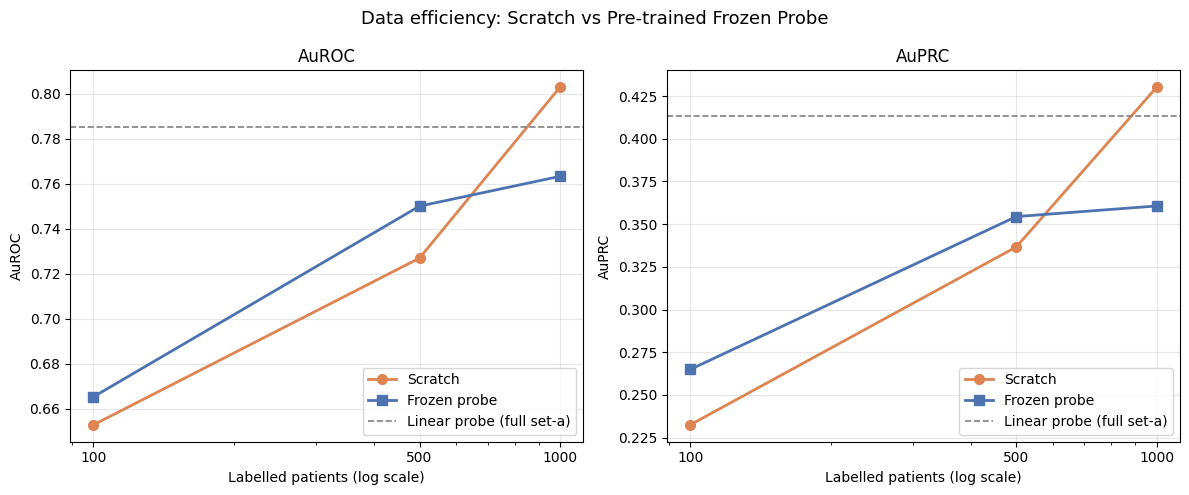

In [48]:
## ── Section 18: Results — data-efficiency summary ─────────────────
res_df = pd.DataFrame(sub_results)

# ── printed table ────────────────────────────────────────────────────
hdr = f"{'n':>6}  {'Model':<14}  {'AuROC':>7}  {'AuPRC':>7}"
print()
print('Data-efficiency — Test set C')
print('=' * len(hdr))
print(hdr)
print('-' * len(hdr))
for _, row in res_df.iterrows():
    print(f"{int(row['n']):>6}  {row['model']:<14}  {row['auroc']:>7.4f}  {row['auprc']:>7.4f}")
print()
print(f"{'full set-a':<21}  {'(linear probe)':}  {test_auroc:>7.4f}  {test_auprc:>7.4f}")
print('=' * len(hdr))

# ── line plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Data efficiency: Scratch vs Pre-trained Frozen Probe', fontsize=13)

for ax, metric, ylabel in [
    (axes[0], 'auroc', 'AuROC'),
    (axes[1], 'auprc', 'AuPRC'),
]:
    for model_name, marker, color in [
        ('Scratch',      'o', '#dd8452'),
        ('Frozen probe', 's', '#4c72b0'),
    ]:
        sub = res_df[res_df['model'] == model_name]
        ax.plot(sub['n'], sub[metric], marker=marker, label=model_name,
                color=color, linewidth=2, markersize=7)
    # Baseline: full linear probe
    baseline = test_auroc if metric == 'auroc' else test_auprc
    ax.axhline(baseline, linestyle='--', color='grey', linewidth=1.2,
               label='Linear probe (full set-a)')
    ax.set_xscale('log')
    ax.set_xticks(SUBSET_SIZES)
    ax.set_xticklabels(SUBSET_SIZES)
    ax.set_xlabel('Labelled patients (log scale)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()